In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip '/content/drive/MyDrive/Tomato Dataset.zip' -d '/content/drive/MyDrive/Tomato Dataset_EfficientNetB5 _test2'

Streaming output truncated to the last 5000 lines.
  inflating: /content/drive/MyDrive/Tomato Dataset_EfficientNetB5 _test2/tomato/train/Tomato___Target_Spot/002213fb-b620-4593-b9ac-6a6cc119b100___Com.G_TgS_FL 8360.JPG  
  inflating: /content/drive/MyDrive/Tomato Dataset_EfficientNetB5 _test2/tomato/train/Tomato___Target_Spot/0044d10f-7062-4655-8abd-9fffc5b2f152___Com.G_TgS_FL 7908.JPG  
  inflating: /content/drive/MyDrive/Tomato Dataset_EfficientNetB5 _test2/tomato/train/Tomato___Target_Spot/00854623-ba28-446d-a1d5-03c0ae3f99d9___Com.G_TgS_FL 7949.JPG  
  inflating: /content/drive/MyDrive/Tomato Dataset_EfficientNetB5 _test2/tomato/train/Tomato___Target_Spot/0118c27a-f34a-41e1-8b2f-d2c564f83c5c___Com.G_TgS_FL 0013.JPG  
  inflating: /content/drive/MyDrive/Tomato Dataset_EfficientNetB5 _test2/tomato/train/Tomato___Target_Spot/0118ed61-b135-45be-ad81-7e2d54203be4___Com.G_TgS_FL 8241.JPG  
  inflating: /content/drive/MyDrive/Tomato Dataset_EfficientNetB5 _test2/tomato/train/Tomato___Targ

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, optimizers, regularizers, callbacks, metrics

In [ ]:
TRAIN_DIR       = "/content/drive/MyDrive/Tomato Dataset_EfficientNetB5 _test2/tomato/train"
VALIDATION_DIR  = "/content/drive/MyDrive/Tomato Dataset_EfficientNetB5 _test2/tomato/val"
IMAGE_SIZE      = (456, 456)
BATCH_SIZE      = 32
EPOCHS          = 30


MEMULAI EXPLORATORY DATA ANALYSIS (EDA)
Total gambar ditemukan: 10000

1. Menganalisis Distribusi Kelas...


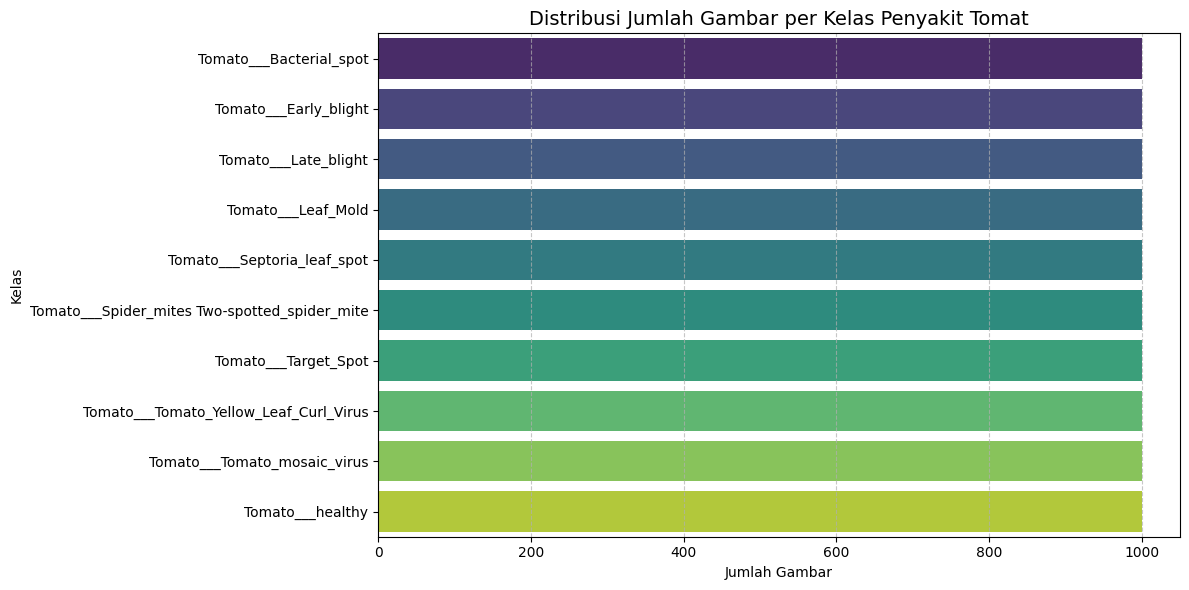

In [ ]:
print("\n" + "="*50)
print("MEMULAI EXPLORATORY DATA ANALYSIS (EDA)")
print("="*50)

filepaths = []
labels = []

for class_name in os.listdir(TRAIN_DIR):
    class_dir = os.path.join(TRAIN_DIR, class_name)
    if os.path.isdir(class_dir):
        for img_name in os.listdir(class_dir):
            filepaths.append(os.path.join(class_dir, img_name))
            labels.append(class_name)

df_eda = pd.DataFrame({'filepath': filepaths, 'label': labels})
print(f"Total gambar ditemukan: {len(df_eda)}")

print("\n1. Menganalisis Distribusi Kelas...")
plt.figure(figsize=(12, 6))
sns.countplot(data=df_eda, y='label', order=df_eda['label'].value_counts().index, palette='viridis', hue='label', legend=False)
plt.title('Distribusi Jumlah Gambar per Kelas Penyakit Tomat', fontsize=14)
plt.xlabel('Jumlah Gambar')
plt.ylabel('Kelas')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
print("\nMengambil seluruh data dari direktori train untuk analisis dimensi dan warna...")

# Ambil semua filepath dari seluruh dataset train
all_filepaths = []
for class_name in os.listdir(TRAIN_DIR):
    class_path = os.path.join(TRAIN_DIR, class_name)
    if os.path.isdir(class_path):
        for fname in os.listdir(class_path):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp')):
                all_filepaths.append(os.path.join(class_path, fname))

print(f"Total gambar ditemukan: {len(all_filepaths)}")

widths, heights = [], []
brightness_vals, contrast_vals = [], []

for i, filepath in enumerate(all_filepaths):
    try:
        img = cv2.imread(filepath)
        if img is not None:
            h, w, _ = img.shape
            widths.append(w)
            heights.append(h)

            hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            brightness_vals.append(np.mean(hsv[:, :, 2]))
            contrast_vals.append(np.std(gray))
    except Exception as e:
        pass

    # Progress log setiap 500 gambar
    if (i + 1) % 500 == 0:
        print(f"  Diproses: {i + 1}/{len(all_filepaths)} gambar...")

print(f"Selesai. Total gambar berhasil dianalisis: {len(widths)}")


Mengambil seluruh data dari direktori train untuk analisis dimensi dan warna...
Total gambar ditemukan: 10000
  Diproses: 500/10000 gambar...
  Diproses: 1000/10000 gambar...
  Diproses: 1500/10000 gambar...
  Diproses: 2000/10000 gambar...
  Diproses: 2500/10000 gambar...
  Diproses: 3000/10000 gambar...
  Diproses: 3500/10000 gambar...
  Diproses: 4000/10000 gambar...
  Diproses: 4500/10000 gambar...
  Diproses: 5000/10000 gambar...
  Diproses: 5500/10000 gambar...
  Diproses: 6000/10000 gambar...
  Diproses: 6500/10000 gambar...
  Diproses: 7000/10000 gambar...
  Diproses: 7500/10000 gambar...
  Diproses: 8000/10000 gambar...
  Diproses: 8500/10000 gambar...
  Diproses: 9000/10000 gambar...
  Diproses: 9500/10000 gambar...
  Diproses: 10000/10000 gambar...
Selesai. Total gambar berhasil dianalisis: 10000


2. Menganalisis Resolusi dan Aspect Ratio...


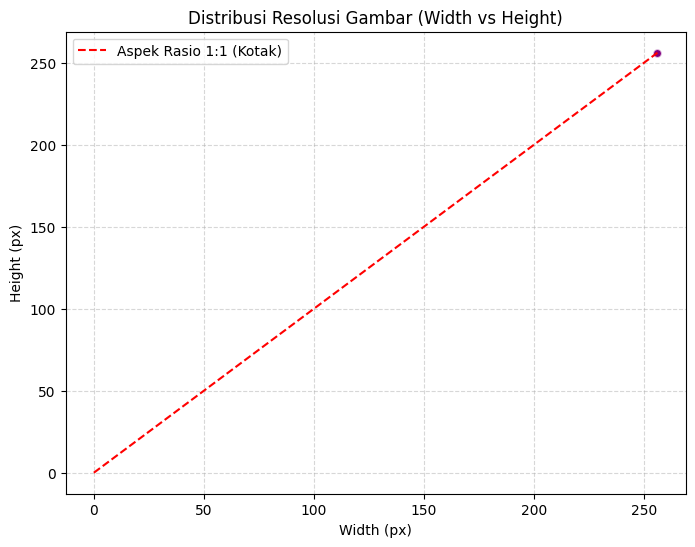

-> Rata-rata Aspect Ratio : 1.00
-> Rata-rata Width        : 256 px
-> Rata-rata Height       : 256 px

3. Menganalisis Kualitas Warna (Brightness, Contrast)...


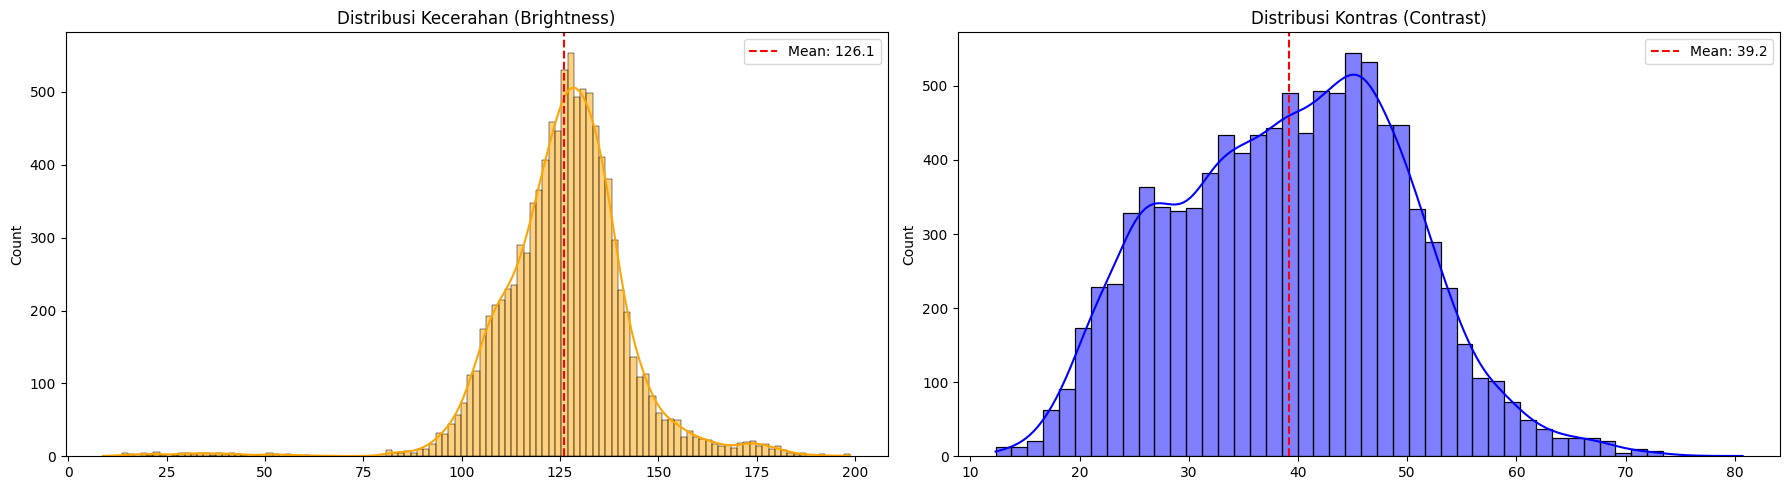

In [ ]:
print("2. Menganalisis Resolusi dan Aspect Ratio...")
plt.figure(figsize=(8, 6))
plt.scatter(widths, heights, alpha=0.5, color='purple', edgecolors='w')
plt.title('Distribusi Resolusi Gambar (Width vs Height)')
plt.xlabel('Width (px)')
plt.ylabel('Height (px)')
max_dim = max(max(widths), max(heights))
plt.plot([0, max_dim], [0, max_dim], 'r--', label='Aspek Rasio 1:1 (Kotak)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

ratios = np.array(widths) / np.array(heights)
print(f"-> Rata-rata Aspect Ratio : {np.mean(ratios):.2f}")
print(f"-> Rata-rata Width        : {np.mean(widths):.0f} px")
print(f"-> Rata-rata Height       : {np.mean(heights):.0f} px")

print("\n3. Menganalisis Kualitas Warna (Brightness, Contrast)...")
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.histplot(brightness_vals, kde=True, ax=axes[0], color='orange')
axes[0].set_title('Distribusi Kecerahan (Brightness)')
axes[0].axvline(x=np.mean(brightness_vals), color='red', linestyle='--', label=f'Mean: {np.mean(brightness_vals):.1f}')
axes[0].legend()

sns.histplot(contrast_vals, kde=True, ax=axes[1], color='blue')
axes[1].set_title('Distribusi Kontras (Contrast)')
axes[1].axvline(x=np.mean(contrast_vals), color='red', linestyle='--', label=f'Mean: {np.mean(contrast_vals):.1f}')
axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
import tensorflow as tf

train_dataset = tf.keras.utils.image_dataset_from_directory(
    directory=TRAIN_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    color_mode="rgb",
    validation_split=0.1765,
    subset="training",
    seed=0
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    directory=TRAIN_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    color_mode="rgb",
    validation_split=0.1765,
    subset="validation",
    seed=0
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    directory=VALIDATION_DIR,
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE,
    label_mode="categorical",
    color_mode="rgb"
)

Found 10000 files belonging to 10 classes.
Using 8235 files for training.
Found 10000 files belonging to 10 classes.
Using 1765 files for validation.
Found 1000 files belonging to 10 classes.


In [ ]:
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
validation_dataset = validation_dataset.prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

In [ ]:
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.25),
    layers.RandomBrightness(0.3),
], name="ekstrem_augmentation")


VISUALISASI HASIL AUGMENTASI DATA
Sampel diambil dari kelas : Tomato___Bacterial_spot
Nama file                 : 247444c2-846f-4626-9c69-762c6f278538___GCREC_Bact.Sp 3452.JPG


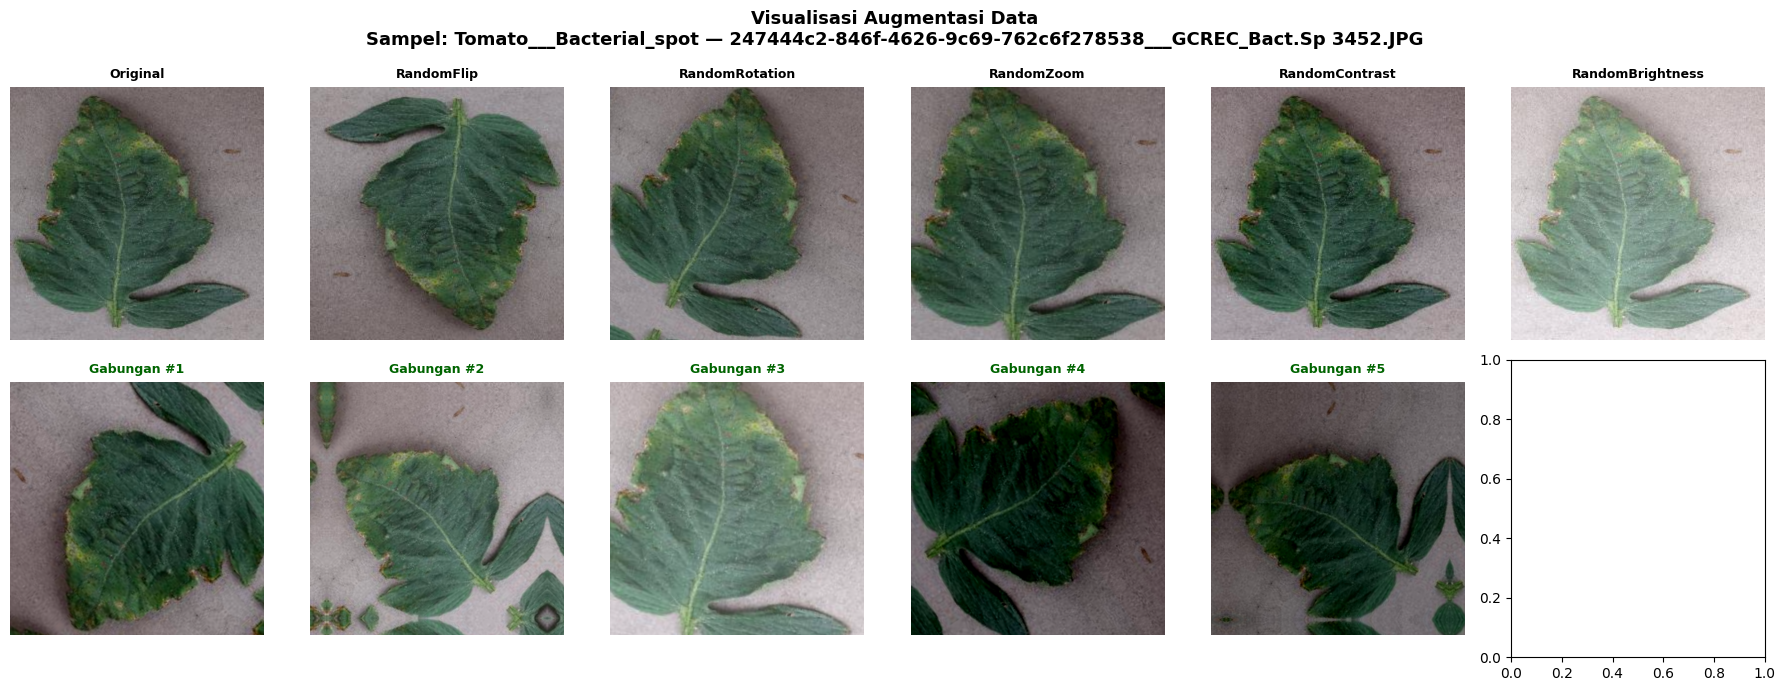

In [ ]:

print("\n" + "="*50)
print("VISUALISASI HASIL AUGMENTASI DATA")
print("="*50)

sample_class = sorted(os.listdir(TRAIN_DIR))[0]
sample_class_path = os.path.join(TRAIN_DIR, sample_class)
sample_fname = [
    f for f in os.listdir(sample_class_path)
    if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp'))
][0]
sample_path = os.path.join(sample_class_path, sample_fname)

img_bgr = cv2.imread(sample_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, IMAGE_SIZE)

print(f"Sampel diambil dari kelas : {sample_class}")
print(f"Nama file                 : {sample_fname}")

img_tensor = tf.cast(tf.expand_dims(img_resized, axis=0), tf.float32)

augmentations = {
    "Original"        : None,
    "RandomFlip"      : layers.RandomFlip("horizontal_and_vertical"),
    "RandomRotation"  : layers.RandomRotation(0.2),
    "RandomZoom"      : layers.RandomZoom(0.2),
    "RandomContrast"  : layers.RandomContrast(0.25),
    "RandomBrightness": layers.RandomBrightness(0.3),
}

N_VARIATIONS = 5
n_cols = max(len(augmentations), N_VARIATIONS)

fig, axes = plt.subplots(2, n_cols, figsize=(n_cols * 3, 7))
fig.suptitle(
    f'Visualisasi Augmentasi Data\nSampel: {sample_class} — {sample_fname}',
    fontsize=13, fontweight='bold'
)

for col_idx, (aug_name, aug_layer) in enumerate(augmentations.items()):
    ax = axes[0][col_idx]
    if aug_layer is None:
        display_img = img_resized
    else:
        augmented = aug_layer(img_tensor, training=True)
        display_img = tf.cast(
            tf.clip_by_value(augmented[0], 0, 255), tf.uint8
        ).numpy()

    ax.imshow(display_img)
    ax.set_title(aug_name, fontsize=9, fontweight='bold')
    ax.axis('off')

# Sembunyikan kolom sisa jika ada
for col_idx in range(len(augmentations), n_cols):
    axes[0][col_idx].axis('off')

# --- Baris 2: Variasi augmentasi gabungan (pipeline penuh) ---
for i in range(N_VARIATIONS):
    ax = axes[1][i]
    augmented = data_augmentation(img_tensor, training=True)
    display_img = tf.cast(
        tf.clip_by_value(augmented[0], 0, 255), tf.uint8
    ).numpy()
    ax.imshow(display_img)
    ax.set_title(f'Gabungan #{i+1}', fontsize=9, fontweight='bold', color='darkgreen')
    ax.axis('off')

# Label baris
axes[0][0].set_ylabel("Per Teknik", fontsize=10, fontweight='bold', labelpad=10)
axes[1][0].set_ylabel("Pipeline Penuh", fontsize=10, fontweight='bold', labelpad=10)

plt.tight_layout()
plt.show()
print("="*50)

In [ ]:
base_model = tf.keras.applications.EfficientNetB5(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMAGE_SIZE, 3)
)
base_model.trainable = False

115263384/115263384 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step


In [ ]:
NUM_CLASSES = 10
model = models.Sequential([
    layers.Input(shape=(*IMAGE_SIZE, 3)),
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax', name='teacher_output')
])

In [ ]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=[
        metrics.CategoricalAccuracy(name='accuracy'),
        metrics.Precision(name='precision'),
        metrics.Recall(name='recall'),
        metrics.AUC(name='auc')
    ]
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ekstrem_augmentation            │ (None, 456, 456, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb5 (Functional)     │ (None, 15, 15, 2048)   │    28,513,527 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ teacher_output (Dense)          │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,785,281 (109.81 MB)

 Trainable params: 267,658 (1.02 MB)

 Non-trainable params: 28,517,623 (108.79 MB)

In [ ]:
early_stopping = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

In [ ]:
import time
from datetime import timedelta

print("\nMemulai Pelatihan Model Guru...")

# Callback custom untuk menghitung waktu epoch
class TimeTrackingCallback(tf.keras.callbacks.Callback):
    def __init__(self):
        self.epoch_times = []
        self.start_time = None

    def on_epoch_begin(self, epoch, logs=None):
        self.start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        epoch_time = time.time() - self.start_time
        self.epoch_times.append(epoch_time)
        print(f"\nEpoch {epoch+1} selesai dalam {epoch_time:.2f} detik")

# Buat callback waktu
time_callback = TimeTrackingCallback()

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping, reduce_lr, time_callback]
)

# Hitung dan tampilkan statistik waktu setelah training selesai
if len(time_callback.epoch_times) > 0:
    avg_epoch_time = sum(time_callback.epoch_times) / len(time_callback.epoch_times)
    total_time = sum(time_callback.epoch_times)

    print("\n" + "="*50)
    print("HASIL WAKTU PELATIHAN")
    print("="*50)
    print(f"Total epoch yang dijalankan: {len(time_callback.epoch_times)}")
    print(f"Waktu rata-rata per epoch:  {avg_epoch_time:.2f} detik ({avg_epoch_time/60:.2f} menit)")
    print(f"Total waktu pelatihan:      {total_time:.2f} detik ({total_time/60:.2f} menit)")
    print(f"Waktu tercepat:            {min(time_callback.epoch_times):.2f} detik")
    print(f"Waktu terlama:             {max(time_callback.epoch_times):.2f} detik")
    print("="*50)
else:
    print("\nTidak ada data waktu epoch yang tersedia.")


Memulai Pelatihan Model Guru...
Epoch 1/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5215 - auc: 0.8636 - loss: 1.8871 - precision: 0.6035 - recall: 0.4605
Epoch 1 selesai dalam 411.01 detik
258/258 ━━━━━━━━━━━━━━━━━━━━ 411s 1s/step - accuracy: 0.6342 - auc: 0.9269 - loss: 1.4464 - precision: 0.7037 - recall: 0.5848 - val_accuracy: 0.8102 - val_auc: 0.9835 - val_loss: 0.8961 - val_precision: 0.9052 - val_recall: 0.6657 - learning_rate: 0.0010
Epoch 2/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7536 - auc: 0.9651 - loss: 1.0445 - precision: 0.7947 - recall: 0.7188
Epoch 2 selesai dalam 349.89 detik
258/258 ━━━━━━━━━━━━━━━━━━━━ 350s 1s/step - accuracy: 0.7593 - auc: 0.9674 - loss: 1.0158 - precision: 0.7965 - recall: 0.7274 - val_accuracy: 0.8397 - val_auc: 0.9863 - val_loss: 0.7349 - val_precision: 0.8655 - val_recall: 0.8164 - learning_rate: 0.0010
Epoch 3/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7812 - auc: 0.9743 - loss: 0.9263 - precision: 0

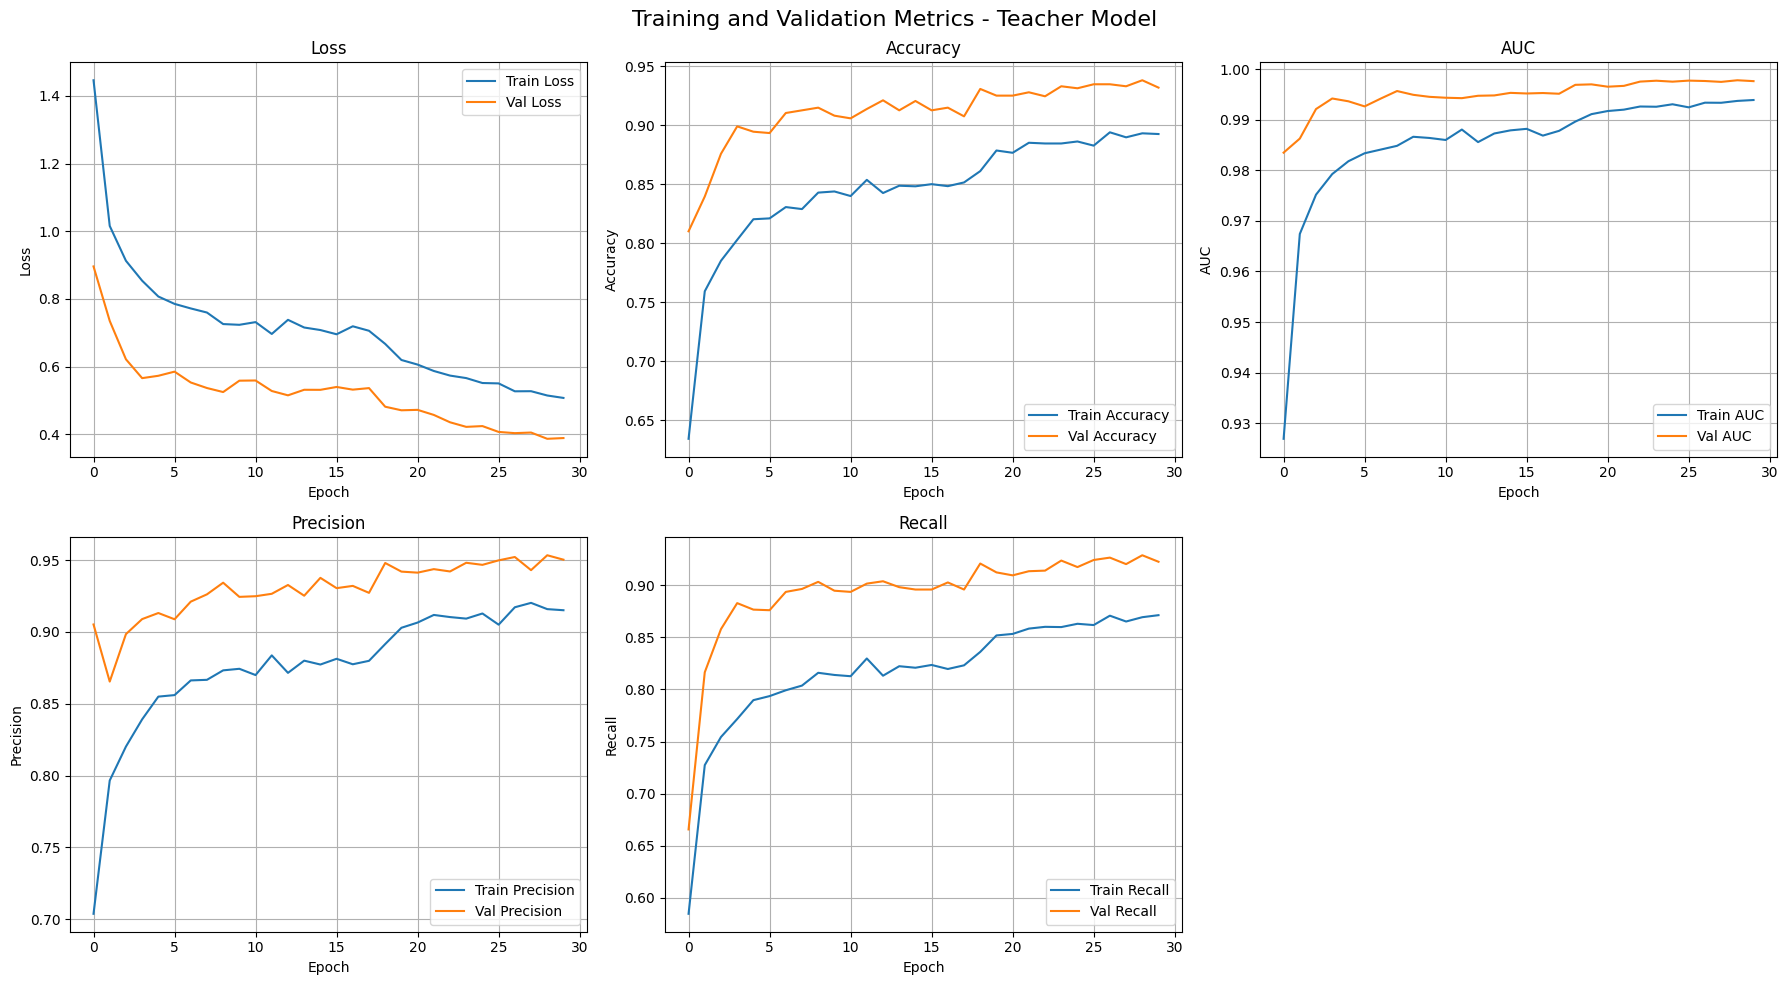

In [ ]:
plt.figure(figsize=(18, 10))
plt.suptitle('Training and Validation Metrics - Teacher Model', fontsize=16)

# 1. Plot Loss
plt.subplot(2, 3, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.title('Loss')

# 2. Plot Accuracy
plt.subplot(2, 3, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.title('Accuracy')

# 3. Plot AUC
plt.subplot(2, 3, 3)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Val AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.grid(True)
plt.title('AUC')

# 4. Plot Precision
plt.subplot(2, 3, 4)
plt.plot(history.history['precision'], label='Train Precision')
plt.plot(history.history['val_precision'], label='Val Precision')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)
plt.title('Precision')

# 5. Plot Recall
plt.subplot(2, 3, 5)
plt.plot(history.history['recall'], label='Train Recall')
plt.plot(history.history['val_recall'], label='Val Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)
plt.title('Recall')

plt.tight_layout()
plt.show()

In [ ]:
print("\n=== 📊 Evaluasi Test Set ===")
results = model.evaluate(test_dataset)
print("\nEvaluation Results:", results)


=== 📊 Evaluasi Test Set ===
32/32 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.9440 - auc: 0.9983 - loss: 0.3700 - precision: 0.9532 - recall: 0.9360

Evaluation Results: [0.3700225055217743, 0.9440000057220459, 0.9531568288803101, 0.9359999895095825, 0.9983336925506592]


In [ ]:
print("\n--- Menyimpan Model ---")
save_path = "/content/drive/MyDrive/Model/EfficientNetB5_Test2.keras"
save_model = model.save(save_path)
print(f"Model berhasil disimpan di: {save_path}")


--- Menyimpan Model ---
Model berhasil disimpan di: /content/drive/MyDrive/Model/EfficientNetB5_Test2.keras


In [ ]:
import time
import os
import tensorflow as tf
import numpy as np

print("\n" + "="*50)
print("🔍 MODEL PERFORMANCE ANALYSIS")
print("="*50)

# 1. Model Size
size_mb = os.path.getsize(save_path)/(1024*1024)
print(f"📦 Model Size     : {size_mb:.2f} MB")

input_shape = (1, IMAGE_SIZE[0], IMAGE_SIZE[1], 3)
dummy = tf.random.normal(input_shape)

print(f"\n⏱️  Testing Inference Speed (IMAGE_SIZE={IMAGE_SIZE})...")

# WARM-UP
print("  Warming up...")
for _ in range(10):
    _ = model(dummy, training=False)

# Test 100 gambar untuk rata-rata akurat
n_test = 100
latencies = []

print(f"  Testing {n_test} images EfficientNet-B0...")
start_total = time.time()

for i in range(n_test):
    start = time.time()
    _ = model(dummy, training=False)
    latency = (time.time() - start) * 1000  # ms
    latencies.append(latency)

end_total = time.time()

# Results
avg_latency = np.mean(latencies[10:])  # Skip first 10
min_latency = np.min(latencies[10:])
max_latency = np.max(latencies[10:])
throughput = 1000 / avg_latency

print(f"\n📈 INFERENCE RESULTS EfficientNet-B0:")
print(f"  Average Latency : {avg_latency:.2f} ms **PER IMAGE**")
print(f"  Min Latency     : {min_latency:.2f} ms")
print(f"  Max Latency     : {max_latency:.2f} ms")
print(f"  Throughput      : {throughput:.1f} images/second")
print(f"  Total {n_test} imgs: {(end_total-start_total)*1000:.2f} ms")

print("\n" + "="*50)


🔍 MODEL PERFORMANCE ANALYSIS
📦 Model Size     : 113.79 MB

⏱️  Testing Inference Speed (IMAGE_SIZE=(456, 456))...
  Warming up...
  Testing 100 images EfficientNet-B0...

📈 INFERENCE RESULTS EfficientNet-B0:
  Average Latency : 681.29 ms **PER IMAGE**
  Min Latency     : 582.84 ms
  Max Latency     : 990.25 ms
  Throughput      : 1.5 images/second
  Total 100 imgs: 68907.35 ms

